### Dataset Description

The **NSL-KDD** dataset is an improved version of the original 1999 KDD Cup dataset, created to
address known issues (duplicate records, biased class distributions) in the older dataset. It
contains network connection records, each described by 41 features (e.g. connection duration,
protocol type, service, byte counts, error rates) plus a label identifying the connection as
either **normal** traffic or one of several **attack** types (grouped into DoS, Probe, R2L, and
U2R categories).

The classification goal is to predict whether a given connection is normal or an intrusion
(variable `label`), and this notebook compares four models for that task: **Logistic Regression**,
**Random Forest**, **XGBoost**, and **SVM**.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
df=pd.read_csv("KDDTrain+.txt")

In [50]:
df.shape

(125972, 43)

#### Data Preprocessing & Exploratory Data Analysis (EDA)

In [51]:
COLUMN_NAMES = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins",
    "logged_in", "num_compromised", "root_shell", "su_attempted",
    "num_root", "num_file_creations", "num_shells", "num_access_files",
    "num_outbound_cmds", "is_host_login", "is_guest_login", "count",
    "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate",
    "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
    "label", "difficulty"
]

In [52]:
df = pd.read_csv("KDDTest+.txt", header=None, names=COLUMN_NAMES)

In [53]:
df

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.00,0.0,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.00,0.0,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.00,0.0,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.00,0.0,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.00,0.0,0.83,0.71,mscan,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22539,0,tcp,smtp,SF,794,333,0,0,0,0,...,0.72,0.06,0.01,0.01,0.01,0.0,0.00,0.00,normal,21
22540,0,tcp,http,SF,317,938,0,0,0,0,...,1.00,0.00,0.01,0.01,0.01,0.0,0.00,0.00,normal,21
22541,0,tcp,http,SF,54540,8314,0,0,0,2,...,1.00,0.00,0.00,0.00,0.00,0.0,0.07,0.07,back,15
22542,0,udp,domain_u,SF,42,42,0,0,0,0,...,0.99,0.01,0.00,0.00,0.00,0.0,0.00,0.00,normal,21


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22544 entries, 0 to 22543
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     22544 non-null  int64  
 1   protocol_type                22544 non-null  object 
 2   service                      22544 non-null  object 
 3   flag                         22544 non-null  object 
 4   src_bytes                    22544 non-null  int64  
 5   dst_bytes                    22544 non-null  int64  
 6   land                         22544 non-null  int64  
 7   wrong_fragment               22544 non-null  int64  
 8   urgent                       22544 non-null  int64  
 9   hot                          22544 non-null  int64  
 10  num_failed_logins            22544 non-null  int64  
 11  logged_in                    22544 non-null  int64  
 12  num_compromised              22544 non-null  int64  
 13  root_shell      

In [55]:
#String columns
print(df.select_dtypes(include="object").columns)

Index(['protocol_type', 'service', 'flag', 'label'], dtype='object')


In [56]:
#Unique values in label column
df['label'].unique()

array(['neptune', 'normal', 'saint', 'mscan', 'guess_passwd', 'smurf',
       'apache2', 'satan', 'buffer_overflow', 'back', 'warezmaster',
       'snmpgetattack', 'processtable', 'pod', 'httptunnel', 'nmap', 'ps',
       'snmpguess', 'ipsweep', 'mailbomb', 'portsweep', 'multihop',
       'named', 'sendmail', 'loadmodule', 'xterm', 'worm', 'teardrop',
       'rootkit', 'xlock', 'perl', 'land', 'xsnoop', 'sqlattack',
       'ftp_write', 'imap', 'udpstorm', 'phf'], dtype=object)

In [57]:
#Copy of df
df_copy=df.copy()

In [58]:
#Sum of null values in df_copy
df_copy.isnull().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [59]:
#Sum of duplicate values
df_copy.duplicated().sum()

np.int64(0)

In [60]:
df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
count,22544.000000,2.254400e+04,2.254400e+04,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,...,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000
mean,218.859076,1.039545e+04,2.056019e+03,0.000311,0.008428,0.000710,0.105394,0.021647,0.442202,0.119899,...,140.750532,0.608722,0.090540,0.132261,0.019638,0.097814,0.099426,0.233385,0.226683,18.017965
std,1407.176612,4.727864e+05,2.121930e+04,0.017619,0.142599,0.036473,0.928428,0.150328,0.496659,7.269597,...,111.783972,0.435688,0.220717,0.306268,0.085394,0.273139,0.281866,0.387229,0.400875,4.270361
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,15.000000,0.070000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000
50%,0.000000,5.400000e+01,4.600000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,168.000000,0.920000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.000000,2.870000e+02,6.010000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.060000,0.030000,0.010000,0.000000,0.000000,0.360000,0.170000,21.000000
max,57715.000000,6.282565e+07,1.345927e+06,1.000000,3.000000,3.000000,101.000000,4.000000,1.000000,796.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [61]:
df["label"].value_counts()

label
normal             9711
neptune            4657
guess_passwd       1231
mscan               996
warezmaster         944
apache2             737
satan               735
processtable        685
smurf               665
back                359
snmpguess           331
saint               319
mailbomb            293
snmpgetattack       178
portsweep           157
ipsweep             141
httptunnel          133
nmap                 73
pod                  41
buffer_overflow      20
multihop             18
named                17
ps                   15
sendmail             14
rootkit              13
xterm                13
teardrop             12
xlock                 9
land                  7
xsnoop                4
ftp_write             3
worm                  2
loadmodule            2
perl                  2
sqlattack             2
udpstorm              2
phf                   2
imap                  1
Name: count, dtype: int64

In [62]:
df["label"].value_counts(normalize=True) * 100

label
normal             43.075763
neptune            20.657381
guess_passwd        5.460433
mscan               4.418027
warezmaster         4.187367
apache2             3.269163
satan               3.260291
processtable        3.038502
smurf               2.949787
back                1.592441
snmpguess           1.468240
saint               1.415011
mailbomb            1.299681
snmpgetattack       0.789567
portsweep           0.696416
ipsweep             0.625444
httptunnel          0.589957
nmap                0.323811
pod                 0.181867
buffer_overflow     0.088715
multihop            0.079844
named               0.075408
ps                  0.066537
sendmail            0.062101
rootkit             0.057665
xterm               0.057665
teardrop            0.053229
xlock               0.039922
land                0.031050
xsnoop              0.017743
ftp_write           0.013307
worm                0.008872
loadmodule          0.008872
perl                0.008872
sqlattac

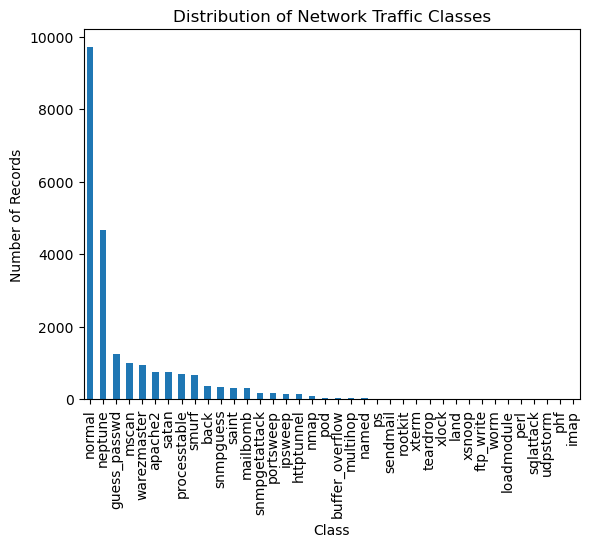

In [63]:
#Categorical attributes
df["label"].value_counts().plot(kind="bar")

plt.title("Distribution of Network Traffic Classes")
plt.xlabel("Class")
plt.ylabel("Number of Records")
plt.xticks(rotation=90)
plt.show()

In [64]:
##it shows data is imbalanced

Normal
normal
DoS attacks

Examples:

neptune
smurf
back
teardrop
pod
Probe attacks

Examples:

satan
ipsweep
portsweep
nmap
R2L attacks

Examples:

warezclient
guess_passwd
ftp_write
imap
U2R attacks

Examples:

buffer_overflow
rootkit
loadmodule
perl

So the individual labels are not random values. They represent different types of network attacks.

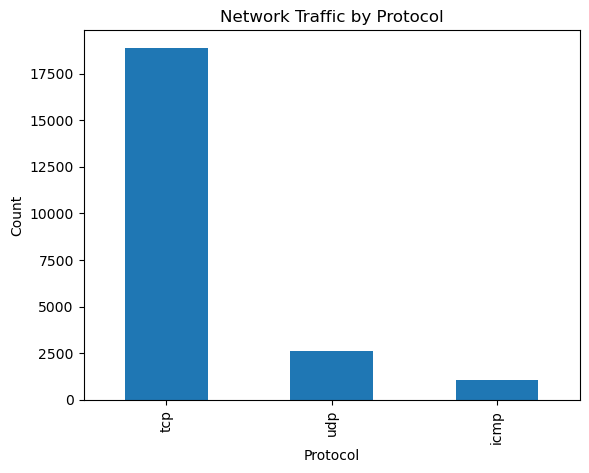

In [65]:
df["protocol_type"].value_counts().plot(kind="bar")

plt.title("Network Traffic by Protocol")
plt.xlabel("Protocol")
plt.ylabel("Count")
plt.show()

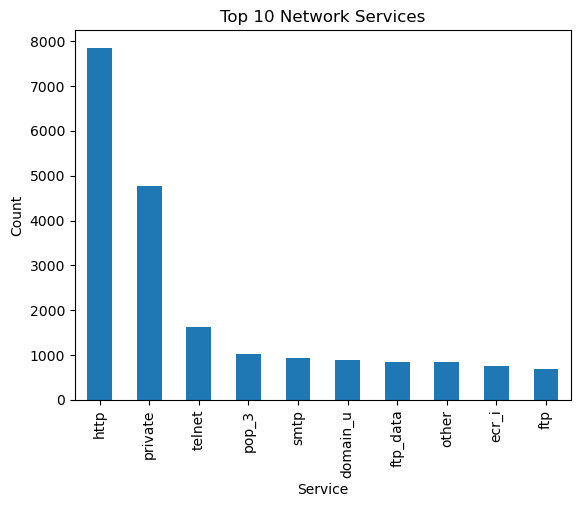

In [66]:
df["service"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Network Services")
plt.xlabel("Service")
plt.ylabel("Count")
plt.show()

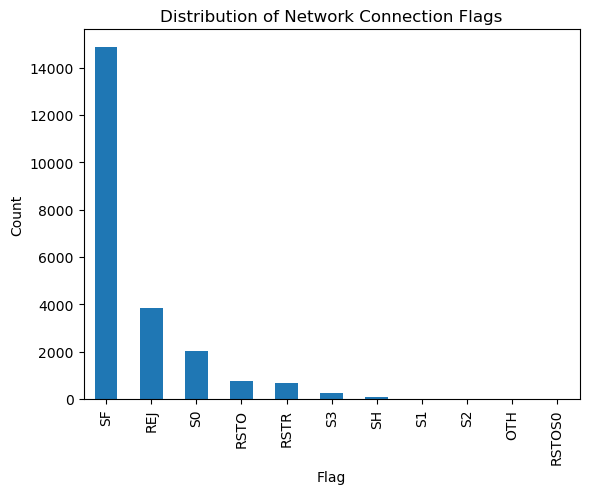

In [67]:
df["flag"].value_counts().plot(kind="bar")

plt.title("Distribution of Network Connection Flags")
plt.xlabel("Flag")
plt.ylabel("Count")
plt.show()

In [68]:
#Binary labeling
df["binary_label"] = df["label"].apply(
    lambda x: "normal" if x == "normal" else "attack"
)

In [69]:
df["binary_label"].value_counts()

binary_label
attack    12833
normal     9711
Name: count, dtype: int64

In [70]:
#Cleaning the label attribute
df["label"] = df["label"].str.strip().str.lower()

In [71]:
df["label"].unique()

array(['neptune', 'normal', 'saint', 'mscan', 'guess_passwd', 'smurf',
       'apache2', 'satan', 'buffer_overflow', 'back', 'warezmaster',
       'snmpgetattack', 'processtable', 'pod', 'httptunnel', 'nmap', 'ps',
       'snmpguess', 'ipsweep', 'mailbomb', 'portsweep', 'multihop',
       'named', 'sendmail', 'loadmodule', 'xterm', 'worm', 'teardrop',
       'rootkit', 'xlock', 'perl', 'land', 'xsnoop', 'sqlattack',
       'ftp_write', 'imap', 'udpstorm', 'phf'], dtype=object)

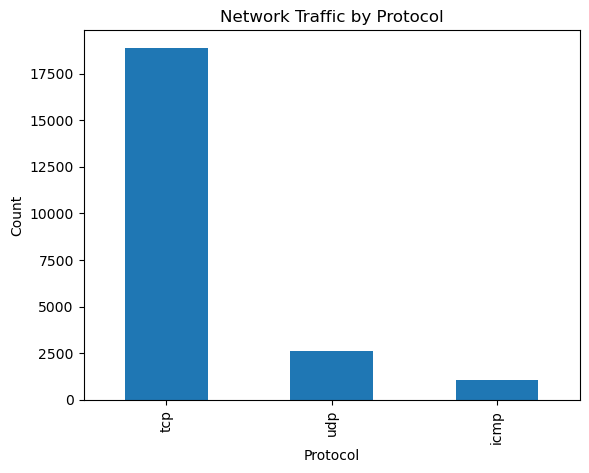

In [72]:
df["protocol_type"].value_counts().plot(kind="bar")

plt.title("Network Traffic by Protocol")
plt.xlabel("Protocol")
plt.ylabel("Count")
plt.show()

### Boxplots for duration, source bytes, destination bytes, num_failed_logins, num_compromised

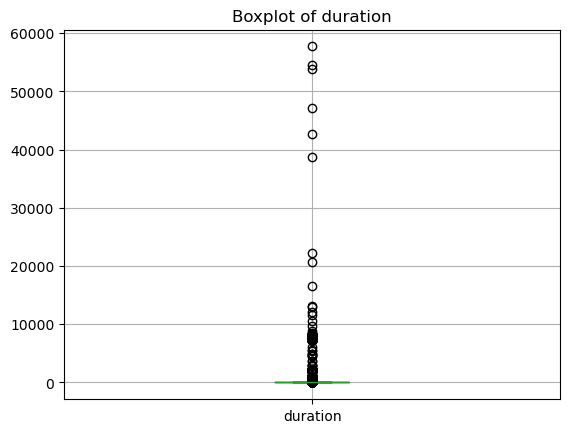

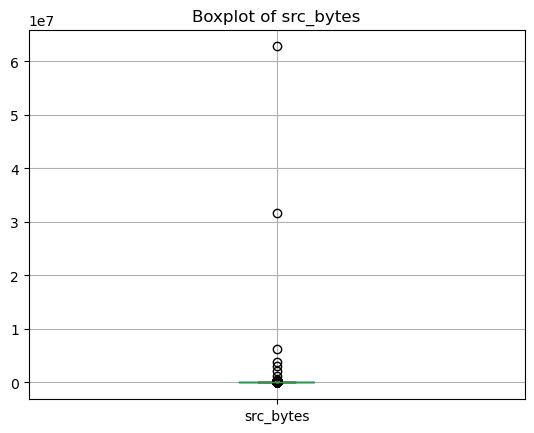

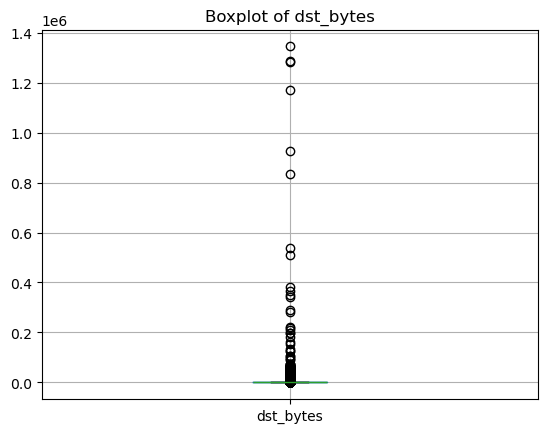

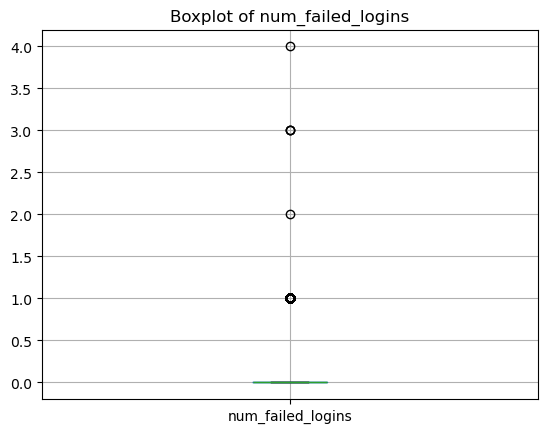

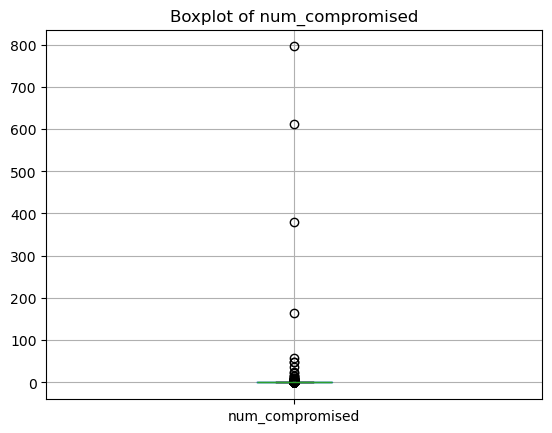

In [73]:
def box_plot(attribute):
    df[[attribute]].boxplot()
    plt.title(f"Boxplot of {attribute}")
    plt.show()

numeric_cols = [
    'duration', 'src_bytes', 'dst_bytes', 'num_failed_logins', 'num_compromised'
]

for col in numeric_cols:
    box_plot(col)


In [74]:
df["src_bytes"].describe()

count    2.254400e+04
mean     1.039545e+04
std      4.727864e+05
min      0.000000e+00
25%      0.000000e+00
50%      5.400000e+01
75%      2.870000e+02
max      6.282565e+07
Name: src_bytes, dtype: float64

Since the amount of data is very large, the box plots are compressed. To fix this issue, logarithm box plot is performed on Source Bytes and Destination Bytes.

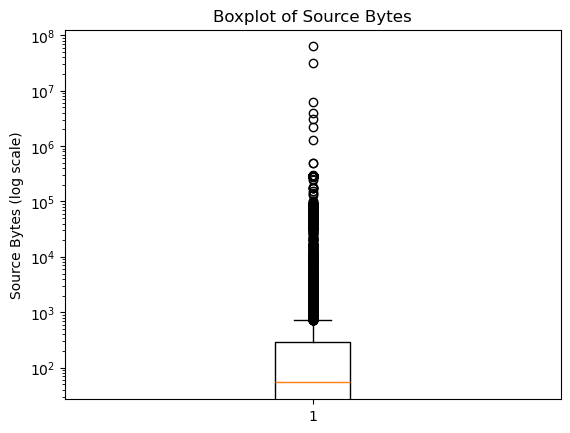

In [75]:
plt.boxplot(df["src_bytes"])

plt.yscale("log")

plt.title("Boxplot of Source Bytes")
plt.ylabel("Source Bytes (log scale)")
plt.show()

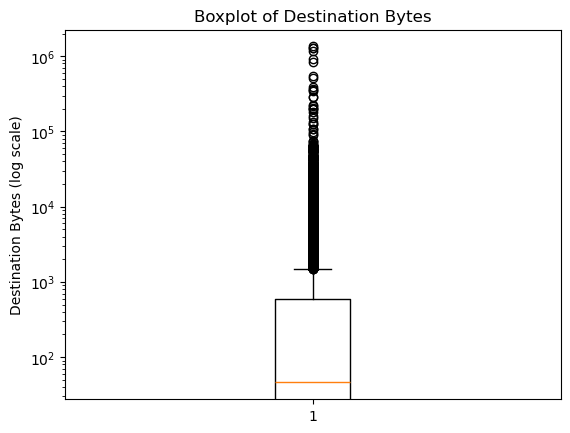

In [76]:
plt.boxplot(df["dst_bytes"])

plt.yscale("log")

plt.title("Boxplot of Destination Bytes")
plt.ylabel("Destination Bytes (log scale)")
plt.show()

### Bar Graph for duration, num_failed_logins, and num_compromised

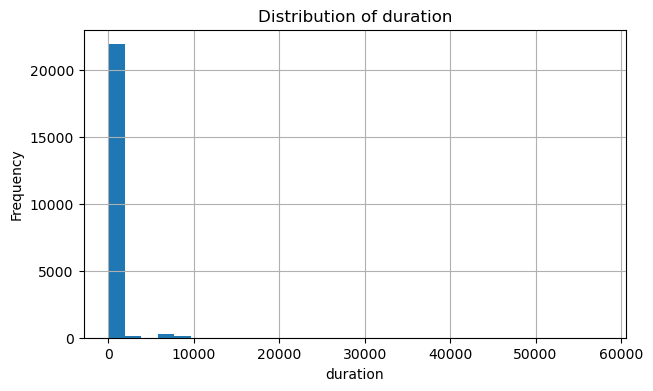

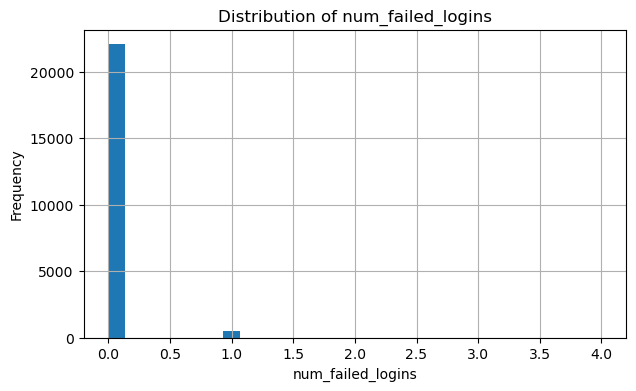

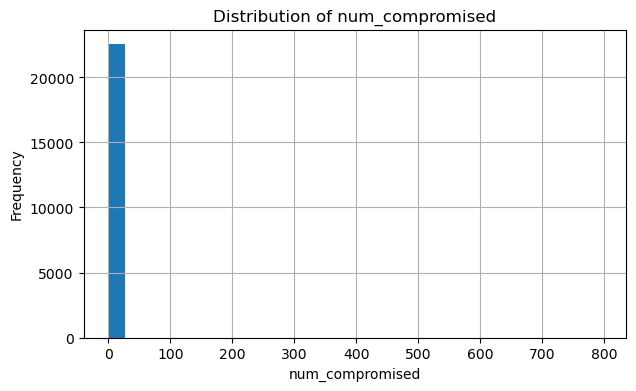

In [77]:
cols = ['duration', 'num_failed_logins', 'num_compromised']

for col in cols:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col], bins=30)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.grid(True)
    plt.show()

In [78]:
#Convert categorical features to category dtype
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category')

In [79]:
#This tells us what categories exist and how many records belong to each.
categorical_cols = ['protocol_type', 'service', 'flag']

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


protocol_type:
protocol_type
tcp     18880
udp      2621
icmp     1043
Name: count, dtype: int64

service:
service
http       7853
private    4774
telnet     1626
pop_3      1019
smtp        934
           ... 
printer      11
ntp_u        10
rje           8
tim_i         6
tftp_u        1
Name: count, Length: 64, dtype: int64

flag:
flag
SF        14875
REJ        3850
S0         2013
RSTO        773
RSTR        669
S3          249
SH           73
S1           21
S2           15
OTH           4
RSTOS0        2
Name: count, dtype: int64


## ???

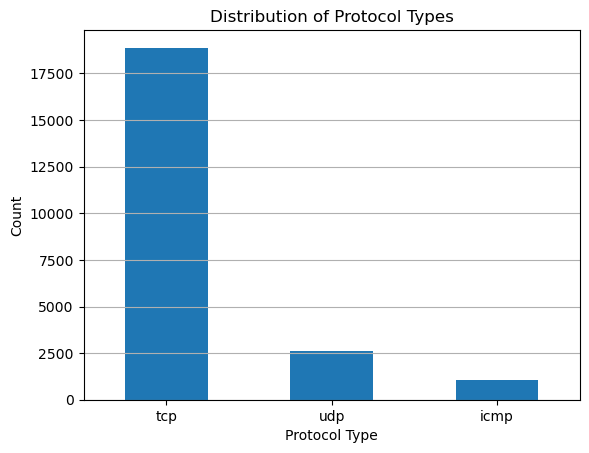

In [80]:
import matplotlib.pyplot as plt

df['protocol_type'].value_counts().plot(kind='bar')

plt.xlabel('Protocol Type')
plt.ylabel('Count')
plt.title('Distribution of Protocol Types')
plt.grid(axis='y')
plt.xticks(rotation=0)
plt.show()

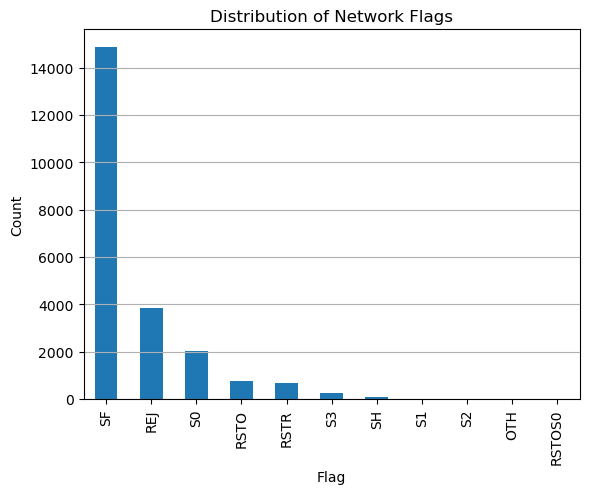

In [81]:
### for flag
df['flag'].value_counts().plot(kind='bar')

plt.xlabel('Flag')
plt.ylabel('Count')
plt.title('Distribution of Network Flags')
plt.grid(axis='y')
plt.show()

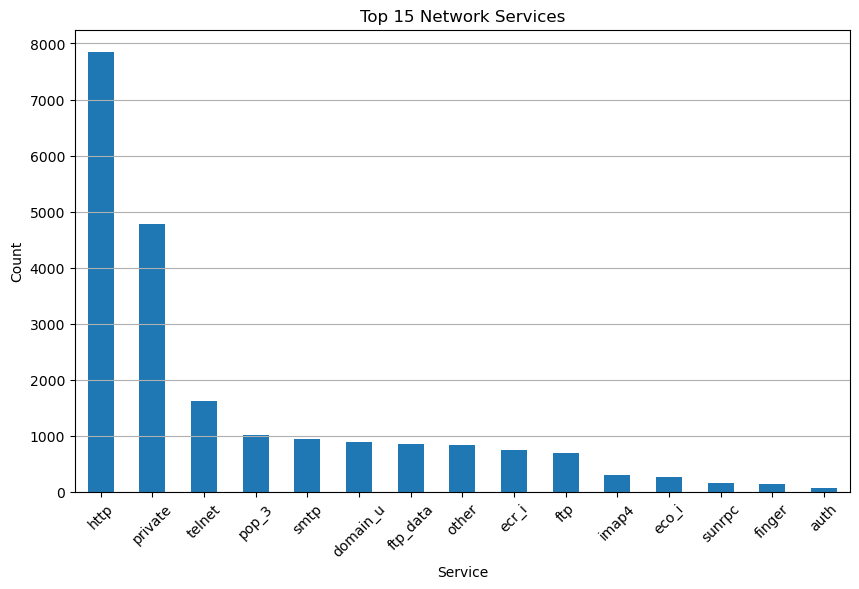

In [82]:
#Distribution of top 15 Network Services
service_counts = df['service'].value_counts()

top_services = service_counts.head(15)

plt.figure(figsize=(10, 6))
top_services.plot(kind='bar')

plt.xlabel('Service')
plt.ylabel('Count')
plt.title('Top 15 Network Services')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

##### Numerical Attributes

In [83]:
numeric_cols = [
    'duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count',
    'serror_rate', 'same_srv_rate', 'dst_host_count', 'dst_host_srv_count'
]

### Correlation Heatmap  of Numerical Features

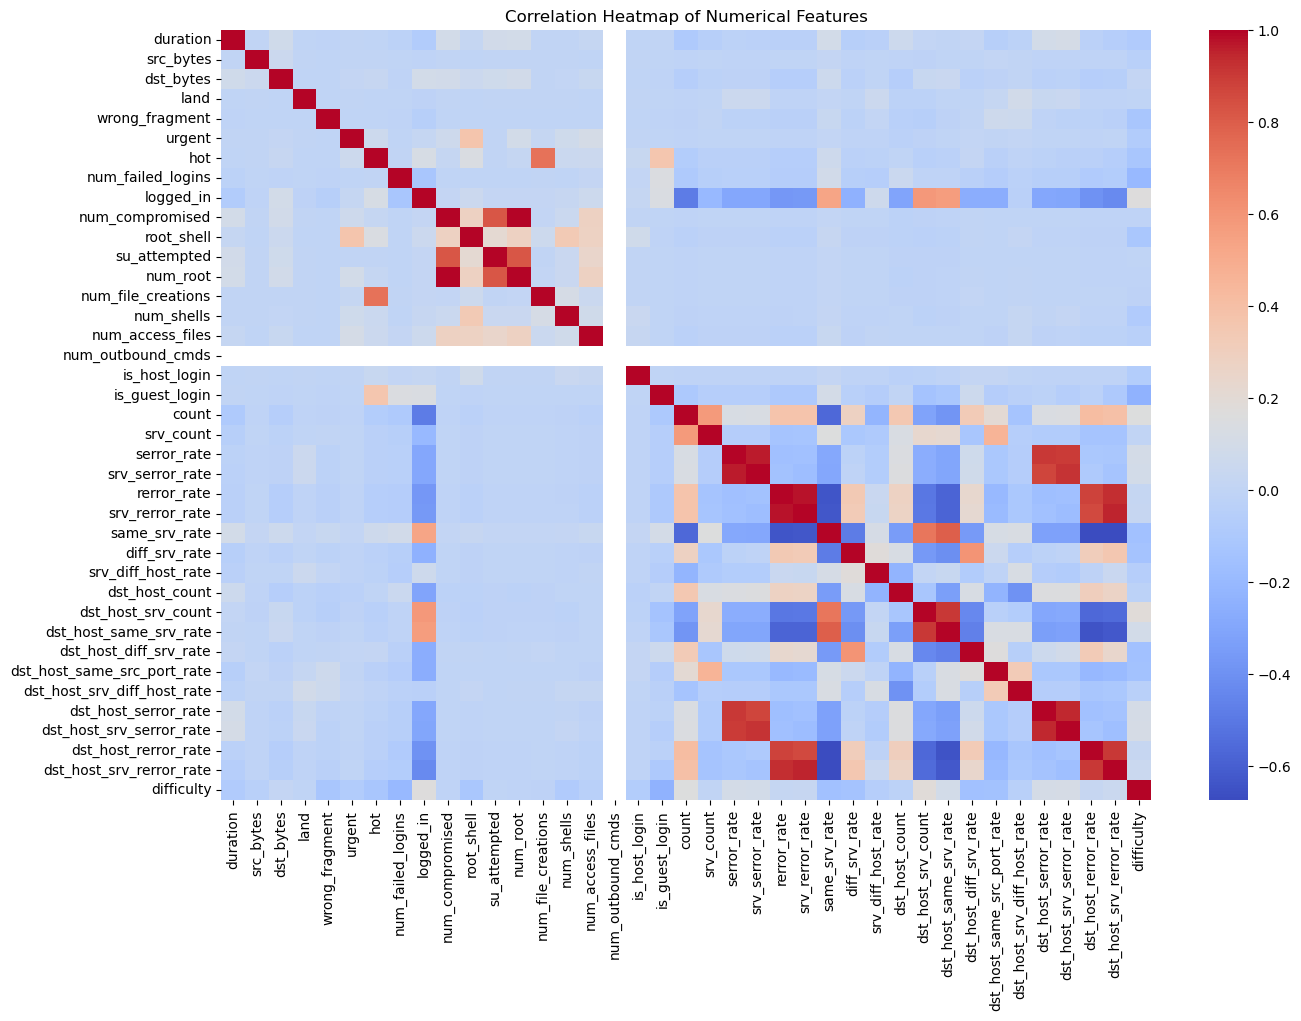

In [84]:
# Select only numerical columns
numeric_df = df.select_dtypes(include='number')

# Calculate correlation
corr = numeric_df.corr()

# Draw heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm')

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

### Correlation Heatmap of selected_cols from numeric_cols

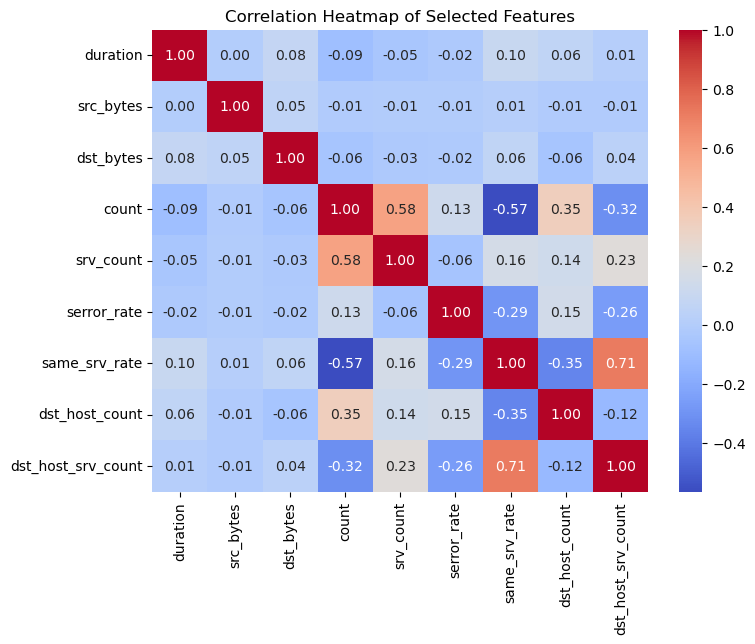

In [85]:
selected_cols = [
    'duration',
    'src_bytes',
    'dst_bytes',
    'count',
    'srv_count',
    'serror_rate',
    'same_srv_rate',
    'dst_host_count',
    'dst_host_srv_count',
   
]

corr = df[selected_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap of Selected Features")
plt.show()

#'num_failed_logins', 'num_compromised'